In [26]:
from skimage.io import imread
import numpy as np
from scipy.io import loadmat
from matplotlib import pyplot as plt
import time
import os

In [27]:
from google.colab import drive
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/Uni/ImageProcessing')
rootfolder = 'Colab Students - Assignments/data'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Load the image and rescale it in $[0,1]$

In [ ]:
img = imread(f'{rootfolder}/cameraman.png') / 255
img = img[50:150, 50:150]
imsz = img.shape

# patch size
p = 7

# number of elements in the patch
M = p ** 2

# radius of the search neighborhood
H = 12

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_60927/1459401155.py", line 1, in <cell line: 0>
    img = imread(f'{rootfolder}/cameraman.png') / 255
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/skimage/_shared/utils.py", line 328, in fixed_func
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/skimage/io/_io.py", line 82, in imread
    img = call_plugin('imread', fname, plugin=plugin, **plugin_args)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/skimage/_shared/utils.py", line 538, in wrapped
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/skimage/io/manage_plugins.py", l

Corrupt the image with white gaussian noise

In [28]:
sigma_noise = 20/255
noisy_img = img + sigma_noise * np.random.randn(*img.shape)
noisy_img = np.clip(noisy_img, 0, 1)
h = 10 * sigma_noise

Compute the PSNR of the noisy input

In [29]:
psnr_noisy = 10 * np.log10(1 / np.mean(np.square(noisy_img - img)))

Text(0.5, 1.0, 'Noisy image, PSNR = 23.25')

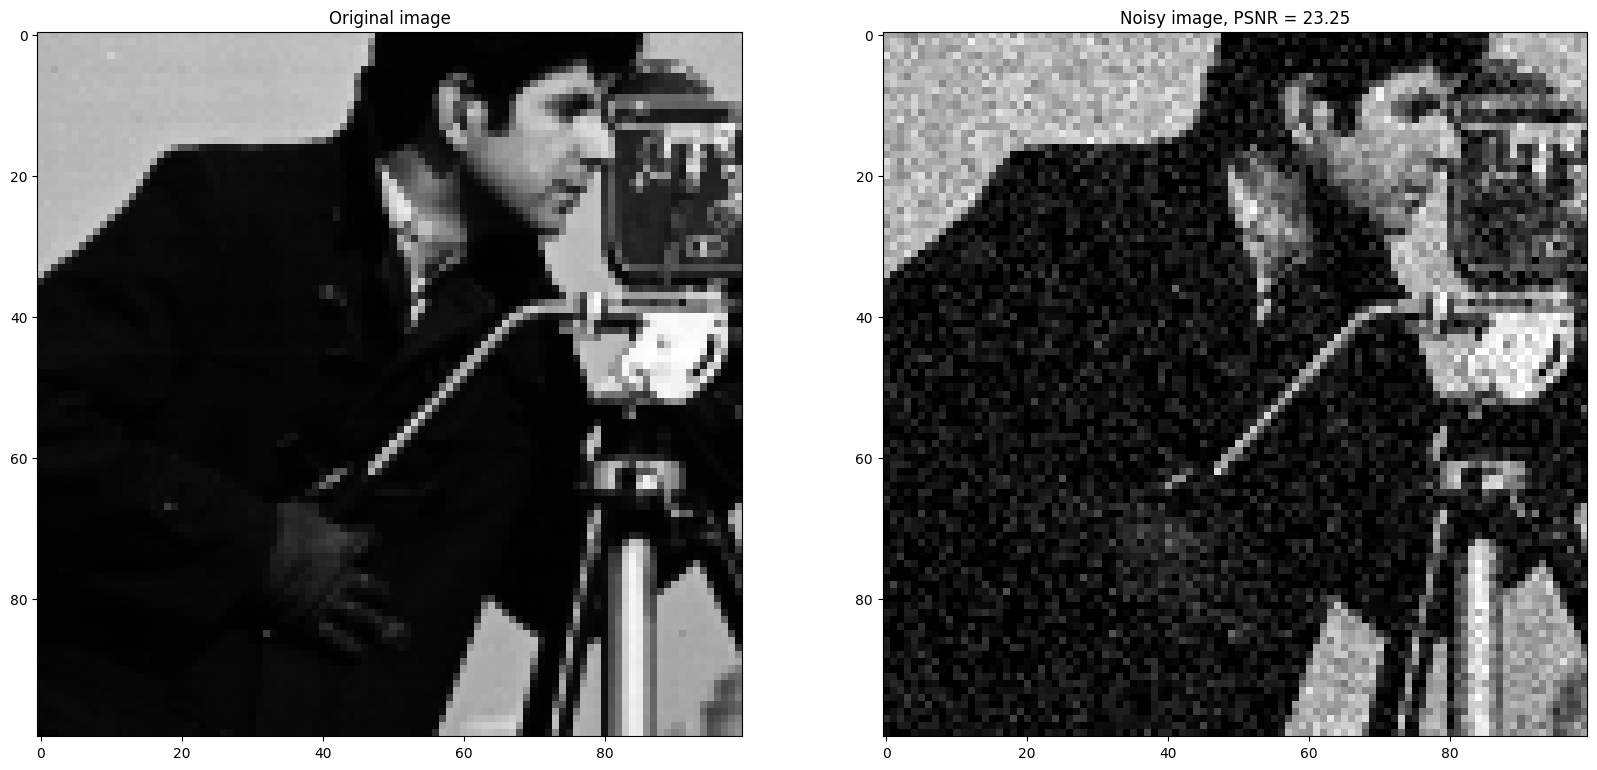

In [30]:
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].imshow(img, cmap='gray')
ax[0].set_title('Original image')

ax[1].imshow(noisy_img, cmap='gray')
ax[1].set_title(f'Noisy image, PSNR = {psnr_noisy:.2f}')


Pixel-based NL-Means
--------------------
Set parameters and initialize the variables

In [31]:
# initialize the estimated image
img_hat = np.zeros_like(img)

# pad the noisy image
img_pad = np.pad(noisy_img, p//2, mode='reflect')


Main loop

In [ ]:
for i in range(0, imsz[0]):
    for j in range(0, imsz[1]):
        # extract the patch from img_pad whose center has the location (i, j) in the noisy image
        s = img_pad[i:i+p, j:j+p]

        # initialize the pixel estimate and the total weights
        pixel_hat = 0
        weight = 0

        # extract all the patches in the search neighborhood
        for r in range(-H, H+1):
            for c in range(-H, H+1):
                # check image boundaries
                if 0 <= i+r < imsz[0] and 0 <= j+c < imsz[1]:
                    # extract the patch
                    z = img_pad[i+r : i+r+p, j+c : j+c+p]

                    # compute the distance with the reference patch
                    dist = np.sum(np.square(s - z))
                    w = np.exp(-dist / (h ** 2))

                    # update the weight and the pixel estimate
                    weight += w
                    pixel_hat += w * noisy_img[i+r, j+c]

        # estimate the pixel (i, j) as the weighted average of the central pixel of the extracted patches
        img_hat[i, j] = pixel_hat / weight

Compute the PSNR of the estimated image

Text(0.5, 1.0, 'Estimated Image,\nPSNR = 26.53')

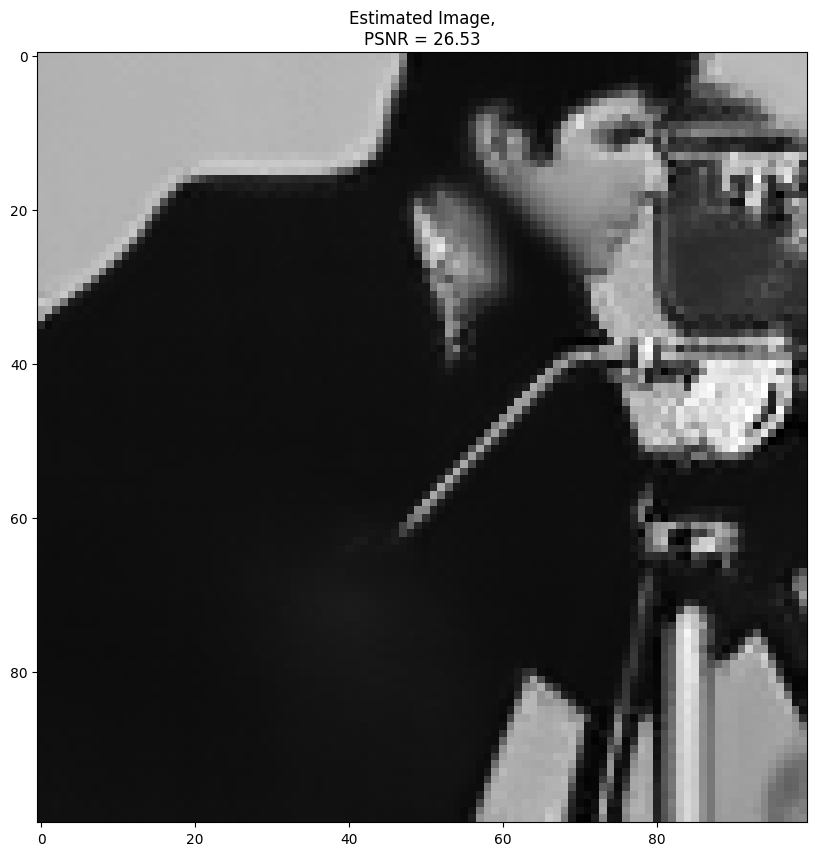

In [ ]:
psnr_hat = 10 * np.log10(1 / np.mean(np.square(img_hat - img)))
plt.figure(figsize=(10,10))
plt.imshow(img_hat, cmap='gray')
plt.title(f'Estimated Image,\nPSNR = {psnr_hat:.2f}')
